<a href="https://colab.research.google.com/github/MamoMGD1/ML_101/blob/main/notebooks/Section06_Natural_Language_Processing/Chapter00_Word_Embeding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **NATURAL LANGUAGE PROCESSING**

Natural Language Processing (NLP) is one of the most fascinating areas in Artificial Intelligence. It is the field that allows machines to process, understand, and respond to **human language** — to be able to think, communicate, and express ideas.  
Importantly, the concept of “natural language” is independent of whether it is English, Chinese, Persian, Arabic, or any other language. The true challenge lies in giving machines the **intelligence to understand *any* language**, regardless of alphabet or grammar rules.

Although research in **“Computer Vision”** had begun earlier (with breakthroughs like AlexNet and ResNet between 2014–2016), NLP rose to prominence more recently (in **2017** with the groundbreaking paper [Attention Is All You Need](https://arxiv.org/abs/1706.03762) by Google.)

Despite starting later than vision research, NLP gained traction extremely quickly due to the **immense variety of tasks** it enables machines to help us with:

- **Translation** – Moving beyond word-by-word translation toward context-aware, fluent systems.  
- **Grammar & Spelling Correction** – Assisting humans in writing clear, professional text.  
- **Sentiment Analysis** – Detecting texts that contain offensive, impolite, and obscene contents.  
- **Summarization** – Condensing large articles, books, or reports into concise key points.  
- **Speech Recognition & Generation** – Seamlessly converting between speech and text.  
- **Text Classification** – Categorizing documents as scientific, historic, literary, journalistic, and more.  
- **Question Answering & Chatbots** – Enabling interactive systems that can respond intelligently.  
- **Information Retrieval** – Finding the most relevant information in massive databases.  
- **Named Entity Recognition (NER)** – Identifying people, places, organizations, and concepts in text.

Each of these tasks reflects a limitation humans had before: translations lacked nuance, spelling tools were rigid, search engines ignored context, and no system could “understand” meaning. NLP resolved all those challenges.

---

## **From Words to Numbers**

We all know that when learning any new language, we have to start from the **smallest meaningful unit** of the language which is a **word**. That’s where both humans and machines must begin.  

Just like a learner of a foreign language tries to connect new words to concepts in their own language, machines also need to transform words and concepts into what they know best: **numbers**.  

The central idea of **Natural Language Processing (NLP)** is simple yet powerful:  
> Find a way to represent words as numbers while preserving the **relationships** between them.  

Imagine we embed every word into a single number (just as an example).  
If the word **“cow”** is mapped to the number **67**, then we’d expect the numbers around 67 to be assigned to the words like **“milk”, “calf”, “bull”, and “beef”** than the word **“keyboard”**.  

Why? Because in natural language, **cow ↔ milk** share a much closer relationship than **cow ↔ keyboard**.  

So, the essence of this chapter is straightforward: we want to discover effective and efficient methods for embedding words into a numerical space in such a way that the similarity and relationships between words in natural language are preserved.

# **WORD EMBEDDING**

Earlier, we gave the example of assigning each word in a dictionary to a single number. Sure, that *technically* counts as embedding words into numerical values — but honestly, it’s the **dumbest idea we could ever use**.  

Why? Think about it: how could we possibly arrange **ALL WORDS** in a line so that their order reflects the richness of their relationships? And for translator models we are dealing with words of multiple languages, not only one.  

It gets even worse when you remember how activation functions like **Tanh** or **Sigmoid** behave. Imagine we’re running a **sentiment analysis** task where we want to detect whether a sentence is polite or offensive. Tanh outputs values between –1 and +1. For inputs smaller than –2, it would saturate near –1 (which we might interpret as “offensive”) and for anything larger than +2, it would saturate near +1 (which we might interpret as “polite”).  

This setup would basically force us to arrange words in a **perfectly smooth numeric scale**. That means the smaller the number we assign to a word, the more it should lack politeness, while the larger the number, the stronger that politeness should become. For example, **“stupid”** might need a slightly lower value than **“silly,”** because while both are offensive, one has a bit lower degree of "politeness" over the other.  

But then we hit a huge problem: **who decides this order, and based on which trait?**  
Do we line up words from offensive to polite? Or from literary to scientific? Or maybe from poetic to slang? Each of these is a valid dimension of language, but a single number cannot possibly capture all of them at once.  

This shows the real limitation:
> Embedding words as single numeric values doesn’t just oversimplify meaning — it actively breaks down the richness of language. Language isn’t **one-dimensional**. It’s **multi-dimensional**, and so should be our embeddings.  

That’s why embedding words into **vectors** — multiple numeric values — is a far better idea. With vectors, we can capture *many different relationships at the same time*, preserving closeness in meaning without forcing an impossible one-dimensional order.  

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S06_C00/2d_embedding.png" width="600">
  <h5>Figure 0: 2-Dimensional embedding space</h5>
</div>

**Image Credit**: [Original Website](https://neptune.ai/blog/word-embeddings-guide)

## **One-Hot Embeddings**

One of the earliest ideas in representing words numerically was **one-hot encoding**. It’s simple, intuitive, and something we already encountered when preprocessing categorical values.  

Here’s how it works:  
- Suppose we have a dictionary of size *d*.  
- For each word, we create a *d*-dimensional vector.  
- Every entry is set to 0 except for a single “1” at the position of that word in the dictionary’s order.  

So, the word at index 7 might look like `[0, 0, 0, 0, 0, 0, 1, 0, 0, ...]`.  

At first glance, this feels neat — every word has a unique representation. But very quickly, the cracks show.  

---

### **The Problems with One-Hot Encoding**

1. **It’s costly and scales badly.**  
   Every vector must have the same length as the entire vocabulary. Adding just one new word means **every single vector and every model parameter** connected to them must resize.  
   For a single language, this might still be tolerable. But imagine extending this to multiple languages — the parameter space explodes, computation slows, and overfitting becomes almost guaranteed.

2. **It ignores relationships between words.**  
   When we care about word similarity, we often measure it using **cosine similarity** (as discussed in `Section00_Chapter01`).  
   But one-hot embeddings create vectors that are all perfectly perpendicular to each other in a high-dimensional space. This means every word is equally distant from every other word.  
   In this space, “cat” is just as unrelated to “dog” as it is to “tissue.” Clearly, this is not how human language works.

3. **It’s inefficient.**  
   The representation wastes enormous space. Almost all entries are zero, which makes these vectors **sparse** and computationally inefficient to handle at scale.

One-hot encoding was a useful **starting point**, a way to get words into numerical form. But it fails in almost every way that matters for language. **We need something denser, smarter, and more meaningful — a way to capture relationships between words inside the vectors themselves.**

## **Word2Vec**

Before diving into the mechanics, let’s pause on a simple but powerful fact: when we collect massive amounts of text — from websites, newspapers, movie subtitles, chat histories which are all unlabelled data — **words that share meaning or have strong relationships tend to appear near each other too often.**

Think about it:  
- In a passage about **bees**, you’ll often see words like *honey, hive, flower, pollen, insect, wasp*.  
- In a passage about **cows**, those words might not happen a lot, instead we'd see *milk, calf, bull, beef, leather*.  

This simple observation unlocks an enormous step forward:  
**context itself provides the supervision signal.**  
Even without someone explicitly labelling words as similar to each other, co-occurrence patterns tell us that “bee” is tied to “honey,” while “cow” is tied to “milk,” and that “bee” and “milk” have nothing to do with each other.   

---

### **From One-Hot to Autoencoders**

Now, how do we turn this idea into a computational model?  
The first step is to feed words into a network as **one-hot vectors** (huge, sparse vectors full of zeros). But instead of keeping them sparse and meaningless, we want to **squeeze them through a bottleneck** into a smaller dense space — say, 100 dimensions — that captures relationships.  

This is where the analogy to an **autoencoder** comes in:  
- The input is the one-hot word vector.  
- The bottleneck produces a dense, compressed representation (the “embedding”).  
- The output layer doesn’t reconstruct the same word — instead, it tries to predict words that **are similar to it,** through two different methods: **CBOW, and Skip-Gram.**

### **Continuous Bag of Words (CBOW)**

The central idea behind CBOW is straightforward:
if we look at the words surrounding a missing word in a sentence, those neighboring words usually carry enough clues to predict what the missing word should be. By repeatedly training a model to perform this kind of prediction across a huge text corpus, we can force it to learn useful **representations of words in a dense vector space**.

The easiest way to see this is with the “fill in the blank” idea.  
Take the sentence:  
**“He wants a ____ rabbit.”**  

If we remove the missing word, the model uses the context window (`He wants a` + `rabbit`) to guess what fits best.  
- Likely candidates: *cute, white, small, sweet*...  
- Unlikely candidates: *watermelon, keyboard*...  

Why? Because in all the training data, “rabbit” rarely (or never) co-occurs with “watermelon” or “keyboard,” but it very often co-occurs with descriptive words like *small* or *cute*.  

This is almost identical to the exercises we solved in elementary school — blank space questions designed to teach us which words are related, which are synonyms, and how context shapes meaning.  

The model does the same thing automatically: words that frequently appear in similar contexts get **squeezed closer together** in the embedding space. Over time, this builds a dense vector space where distance reflects real semantic similarity.  

We had the same idea in the previous section as well if you remember. We witnessed how autoencoders had the ability to reconstruct an image with noisy, cropped, or randomly dropped pixels, just by looking at a large number of original images. In NLP the concept is the same, but this time we are dealing with **missing words in sentences** instead of **missing pixels in images.**


### **Skip-Gram**  

It flips the idea behind CBOW: instead of predicting the center word from its neighbors, we’ll predict the **neighbors from the center word**.  

Imagine sliding a window across a sentence. At every step, Skip-Gram takes the **center word** as input and tries to predict each word that falls within the surrounding window.  

Let’s take a very simple sentence:  

**“A cute rabbit ate the carrot.”**

If our window size is 2, the center word is **“rabbit”**.
Skip-Gram will try to generate training pairs like:

* (rabbit → a)
* (rabbit → cute)
* (rabbit → ate)
* (rabbit → carrot)

So the model is literally learning:

> “When I see the word **rabbit**, I should also expect to see words like **cute, a, ate, carrot** somewhere nearby. (we would most of the times remove stop words like "The" and "A/An")”

Over millions of sentences, this mechanism forces the model to recognize that certain words **co-occur frequently** with others.

- For “rabbit” it will often see: *cute, white, small, cage, carrot, pet…*  
- For “football” it might often see: *team, match, stadium, player, score…*  
- But “rabbit” and “stadium” will almost **never** co-occur.  

This difference is exactly what shapes the embeddings: words that share many neighbors in common end up close to each other in the embedding space.  

---

### **Why Skip-Gram over CBOW?**

At first glance, CBOW might seem more rational:  
use many words (the context) to predict a single one (the center). But in practice, Skip-Gram often performs **better** for a few reasons:  

1. **Rare Words Benefit More**  
   - CBOW averages the surrounding context, which can “wash out” information about rare words.  
   - Skip-Gram directly pairs the center word with each context word, giving rare words more chances to adjust their embeddings.  

2. **Finer-Grained Learning**  
   - Since Skip-Gram creates multiple training pairs for each word, it captures richer statistical information about word co-occurrence.  

## **Skip-Gram Implementation**  

We already understand the *idea* of Skip-Gram:  
pick a **center word**, predict its **context words**, and learn embeddings by forcing words that co-occur to land close together.  

This code is a **minimal but complete implementation** of that idea. Let’s break it down step by step.  

---

### **Vocabulary Class**  

This part is all about **preparing the words** for the model:  

- **`word2idx` & `idx2word`**:  
  These are simple dictionaries that map words to unique indices (and back).  
  Neural networks don’t understand strings, so we need indices.  

- **Stopwords filter**:  
  Notice the big set of *articles, conjunctions, prepositions, auxiliaries…* These are removed because they add almost no semantic meaning (e.g., “the”, “is”, “and”). Keeping them would only waste embedding capacity.  

- **`build_vocab` method**:  
  - Counts words across all sentences.  
  - Removes stopwords.  
  - Applies `min_count` filtering (ignores rare words).  
  - Assigns each valid word an index.  
  - Stores total vocab size and frequency counts.  

---

### **SkipGramData Class**  

This is where Skip-Gram actually **generates training pairs**.  

- **`window_size`**: defines how many neighbors to look at on each side.  
  Example: with size = 2, it looks at 2 words before and 2 after the center word.  

- **`generate_training_data`**:  
  - Converts words in a sentence into indices.  
  - Slides a window across the sentence.  
  - For each center word, collects `(center, context)` pairs.  

---

### **SkipGramModel Class**  

Here’s the real learning engine.  

### Parameters  
- **`embed_size`**: size of embedding vectors (e.g., 8, 100, 300).  
- **`W`**: input embeddings (center words).  
- **`W_out`**: output embeddings (context words).  

---

## **Training Loop**  


1. **Negative Sampling Distribution**:  
   - Instead of predicting *every* word in vocab (expensive), we sample a few random “negative” words that shouldn’t appear.  
   - Uses a smoothed unigram distribution (`**0.75`) — a famous Word2Vec trick to balance common and rare words.  

2. **For each training pair (center, context):**  
   - Compute similarity (dot product) between center word vector and context word vector.  
   - Pass through sigmoid → probability this context is correct.  
   - Update both `W` and `W_out` with gradients.  

3. **For negative samples:**  
   - Do the same process, but push their similarity away from the center word.  
   - This ensures “rabbit” isn’t close to “keyboard”, unless data proves otherwise.   

This implementation shows the **entire Skip-Gram pipeline** in action:  

1. Clean text and decide what words matter (`Vocabulary`).  
2. Turn raw sentences into training pairs (`SkipGramData`).  
3. Train embeddings with negative sampling (`SkipGramModel`).  
4. Explore relationships and analogies between words.  

It connects the theory we’ve been discussing — *co-occurrence, windows, negative sampling* — directly into working code.  

In [ ]:
import numpy as np
from collections import defaultdict
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import re

In [ ]:
class Vocabulary:
    def __init__(self):
        self.word2idx = {}
        self.idx2word = {}
        self.word_count = defaultdict(int)
        self.vocab_size = 0
        self.total_words = 0
        # Stopwords: articles, conjunctions, prepositions, auxiliaries
        self.stopwords = {
            # Articles
            'a', 'an', 'the',
            # Conjunctions
            'for', 'and', 'not', 'but', 'or', 'yet', 'so',
            # Prepositions
            'as', 'in', 'on', 'at', 'to', 'from', 'by', 'with', 'about', 'above', 'across',
            'after', 'against', 'along', 'among', 'around', 'before', 'behind',
            'below', 'beneath', 'beside', 'between', 'beyond', 'during', 'inside',
            'into', 'near', 'off', 'onto', 'over', 'past', 'through', 'toward',
            'towards', 'under', 'until', 'upon', 'within', 'without',
            # Other non-meaningful words (auxiliaries, determiners, etc.)
            'is', 'are', 'was', 'were', 'be', 'been', 'all', 'some', 'any', 'this',
            'that', 'these', 'those', 'while', 'when', 'where', 'who', 'what'
        }

    def build_vocab(self, sentences, min_count=2):
        """Build vocabulary, filtering stopwords and words below min_count."""
        for sentence in sentences:
            for word in sentence:
                if word not in self.stopwords:  # Skip stopwords
                    self.word_count[word] += 1
        idx = 0
        for word, count in self.word_count.items():
            if count >= min_count and word not in self.stopwords:
                self.word2idx[word] = idx
                self.idx2word[idx] = word
                idx += 1
        self.vocab_size = len(self.word2idx)
        self.total_words = sum(count for word, count in self.word_count.items() if count >= min_count and word not in self.stopwords)

    def word_to_index(self, word):
        """Return index of a word or -1 if not found."""
        return self.word2idx.get(word, -1)

    def index_to_word(self, index):
        """Return word for a given index or None if not found."""
        return self.idx2word.get(index, None)

class SkipGramData:
    def __init__(self, window_size=2):
        """
        Initialize with window_size (number of context words on each side of center).
        E.g., window_size=2 means 2 words before + center + 2 words after = 5-word window.
        """
        self.window_size = window_size

    def generate_training_data(self, vocab, sentences):
        """
        Generate (center_word, context_word) pairs for Skip-Gram training.
        For each word in a sentence, treat it as the center and pair it with
        context words within window_size on either side.
        E.g., for window_size=2, total window is 5 words (2 before, center, 2 after).
        """
        training_data = []
        for sentence in sentences:
            # Convert words to indices, skipping unknown words
            sentence_indices = [vocab.word_to_index(word) for word in sentence if vocab.word_to_index(word) != -1]
            for center_idx, center_word in enumerate(sentence_indices):
                # Define context window: window_size words before and after center
                start = max(0, center_idx - self.window_size)
                end = min(len(sentence_indices), center_idx + self.window_size + 1)
                for context_idx in range(start, end):
                    if context_idx != center_idx:  # Exclude center word itself
                        context_word = sentence_indices[context_idx]
                        training_data.append((center_word, context_word))
        return np.array(training_data)

def normalize_rows(mat):
    return mat / (np.linalg.norm(mat, axis=1, keepdims=True) + 1e-10)

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

class SkipGramModel:
    def __init__(self, vocab_size, embed_size=8, learning_rate=0.01, neg_k=5):
        self.vocab_size = vocab_size
        self.embed_size = embed_size
        self.lr = learning_rate
        self.neg_k = neg_k
        np.random.seed(42)
        self.W = np.random.normal(0, 0.1, (vocab_size, embed_size))  # input embeddings
        self.W_out = np.zeros((vocab_size, embed_size))  # output embeddings

    def softmax(self, x):
        """Compute softmax for a vector."""
        exp_x = np.exp(x - np.max(x))
        return exp_x / np.sum(exp_x)

    def train(self, training_data, epochs=100):
        # Precompute unigram distribution for negative sampling (optionally with smoothing)
        counts = np.ones(self.vocab_size)
        unigram = counts / counts.sum()
        neg_dist = unigram ** 0.75
        neg_dist = neg_dist / neg_dist.sum()

        for epoch in range(epochs):
            np.random.shuffle(training_data)
            loss = 0.0
            for center_idx, context_idx in training_data:
                v_c = self.W[center_idx]          # input vector
                # positive sample
                z = np.dot(self.W_out[context_idx], v_c)
                p_pos = sigmoid(z)
                grad_out_pos = (p_pos - 1.0)     # derivative for output vector
                # update output and input
                self.W_out[context_idx] -= self.lr * grad_out_pos * v_c
                self.W[center_idx] -= self.lr * grad_out_pos * self.W_out[context_idx]

                loss -= np.log(p_pos + 1e-10)

                # negative samples
                neg_samples = np.random.choice(self.vocab_size, size=self.neg_k, p=neg_dist)
                for neg in neg_samples:
                    z_neg = np.dot(self.W_out[neg], v_c)
                    p_neg = sigmoid(z_neg)
                    grad_out_neg = p_neg  # derivative for negative
                    self.W_out[neg] -= self.lr * grad_out_neg * v_c
                    self.W[center_idx] -= self.lr * grad_out_neg * self.W_out[neg]
                    loss -= np.log(1 - p_neg + 1e-10)

            if (epoch+1) % max(1, epochs//10) == 0:
                print(f"Epoch {epoch+1}, Loss {loss:.4f}")

        # final embedding is input matrix W
        self.W = self.W / (np.linalg.norm(self.W, axis=1, keepdims=True) + 1e-10)

    def get_embedding(self, word, vocab):
        """Return embedding vector for a word."""
        idx = vocab.word_to_index(word)
        if idx == -1:
            raise ValueError(f"Word '{word}' not in vocabulary")
        return self.W[idx]

    def find_similar_words(self, word, vocab, top_n=5):
        idx = vocab.word_to_index(word)
        if idx == -1:
            return []
        W_norm = normalize_rows(self.W)
        vec = W_norm[idx]
        sims = W_norm.dot(vec)
        # exclude the word itself
        sims[idx] = -np.inf
        top_idx = np.argsort(sims)[::-1][:top_n]
        return [(vocab.index_to_word(i), float(sims[i])) for i in top_idx]

    def solve_analogy(self, a, b, c, vocab, top_n=5):
        # a : b :: c : ?
        try:
            ia = vocab.word_to_index(a)
            ib = vocab.word_to_index(b)
            ic = vocab.word_to_index(c)
        except:
            return None
        if ia == -1 or ib == -1 or ic == -1:
            raise ValueError("One of the words not in vocab")
        W_norm = normalize_rows(self.W)
        vec_a = W_norm[ia]
        vec_b = W_norm[ib]
        vec_c = W_norm[ic]
        vec_d = vec_c + (vec_b - vec_a)
        sims = W_norm.dot(vec_d)
        # Exclude a, b, c from candidates
        sims[[ia, ib, ic]] = -np.inf
        top_idx = np.argsort(sims)[::-1][:top_n]
        return vocab.index_to_word(top_idx[0])

    def visualize_embeddings(self, words, vocab):
        """Visualize word embeddings in 2D using t-SNE."""
        embeddings = np.array([self.get_embedding(word, vocab) for word in words])
        tsne = TSNE(n_components=2, random_state=42, perplexity=5)
        reduced = tsne.fit_transform(embeddings)

        plt.figure(figsize=(6, 5))
        plt.scatter(reduced[:, 0], reduced[:, 1], c='blue')
        for i, word in enumerate(words):
            plt.annotate(word, (reduced[i, 0]-3, reduced[i, 1]+2))
        plt.title("Word Embeddings in 2D (t-SNE)")
        plt.xlabel("t-SNE Component 1")
        plt.ylabel("t-SNE Component 2")
        plt.grid(True)
        plt.show()

### **Embedded Vector Similarities**

We wrote a simple passage that looks like a **farm story**, but in reality, it has no deeper meaning — it’s just a sequence of words arranged into sentences. What matters is not the story itself, but the **patterns of co-occurrence** between words. It resembles a simple passage.

During training, Skip-Gram scans through these sentences and generates pairs of **center words** and their **context words**. Over many iterations, the model learns which words tend to appear together.

When we finally query the model, the results show meaningful groupings:

* *Chicken* clusters with **nest, rooster, hen**
* *Sheep* clusters with **lamb, ram, pasture**
* *Cow* clusters with **milk, calf, field**

It seems like the model discovered relationships — showing us that embeddings capture **semantic similarity** purely from usage patterns.

In [ ]:
farm_story = """
On the farm the chicken clucked egg nest hen rooster. The hen pecked grain chicken rooster egg nest. The rooster crowed chicken hen nest egg. The egg lay nest chicken hen rooster. The nest held chicken egg hen rooster.
The cow grazed field milk calf cow milk. The calf drank milk cow grazing milk field. The cow stood field feeding calf milk. The calf followed cow milk grazing cow. The milk flowed cow calf field grazing.
The sheep wandered pasture lamb ram sheep lamb. The lamb followed sheep ram pasture grazing sheep. The ram led sheep lamb pasture bleating ram. The sheep bleated lamb ram grazing pasture. The lamb grazed sheep ram pasture quiet.
The goat climbed hill kid goat hill kid. The kid leaped near goat nibbling leaves goat kid. The goat chewed leaves kid climbing goat hill. The kid followed goat hill goat leaves kid. The goat stood hill chewing leaves kid goat.
The horse galloped pasture foal horse foal. The foal ran near horse galloping pasture foal horse. The horse neighed pasture foal grazing horse foal. The foal followed horse galloping pasture foal horse. The horse trotted field pasture foal horse.
The duck quacked pond duck pond duck. The duck swam pond duck waddled pond duck. The pig slept mud pig barn pig. The pig wallowed mud pig snoring pig.
"""

# Preprocess the passage
def preprocess_text(text):
    """Tokenize text into sentences and words, lowercase, remove punctuation."""
    text = text.lower()
    sentences = re.split(r'[.!?]', text)
    sentences = [s.strip().split() for s in sentences if s.strip()]
    return sentences

# Prepare data
sentences = preprocess_text(farm_story)

# Build vocabulary
vocab = Vocabulary()
vocab.build_vocab(sentences, min_count=3)  # Keep all words for small corpus
print(f"Vocabulary size: {vocab.vocab_size}")

# Generate training data
data_gen = SkipGramData(window_size=4)
training_data = data_gen.generate_training_data(vocab, sentences)
print(f"Training pairs generated: {len(training_data)}")

# Train Skip-Gram model
model = SkipGramModel(vocab_size=vocab.vocab_size, embed_size=12, learning_rate=0.002)
model.train(training_data, epochs=400)

# Notice how similar their embedded vectors are
print("\ncow:", model.get_embedding("cow", vocab))
print("milk:", model.get_embedding("milk", vocab))

Vocabulary size: 24
Training pairs generated: 624
Epoch 40, Loss 1678.0435
Epoch 80, Loss 1368.6562
Epoch 120, Loss 1068.1853
Epoch 160, Loss 968.5154
Epoch 200, Loss 924.9596
Epoch 240, Loss 927.1808
Epoch 280, Loss 916.5496
Epoch 320, Loss 909.4155
Epoch 360, Loss 892.1432
Epoch 400, Loss 882.4800

cow: [-0.20997059  0.02154565 -0.597056   -0.28333815 -0.04260838  0.58676213
  0.08948985  0.13248484 -0.08266224 -0.20088943  0.22632429  0.22048477]
milk: [-0.22015915  0.03505656 -0.54400252 -0.21921881 -0.16828931  0.6876092
  0.13100219  0.14827369 -0.17167905 -0.14699063  0.11886656  0.0286671 ]


In [ ]:
# Query related words
query_words = ["chicken", "sheep", "cow"]
for word in query_words:
    try:
        related = model.find_similar_words(word, vocab, top_n=3)
        print(f"\nTop 3 words related to '{word}':")
        for sim_word, score in related:
            print(f"  {sim_word}: {score:.4f}")
    except ValueError as e:
        print(e)


Top 3 words related to 'chicken':
  nest: 0.9345
  rooster: 0.9243
  hen: 0.8997

Top 3 words related to 'sheep':
  lamb: 0.9487
  ram: 0.9337
  pasture: 0.6924

Top 3 words related to 'cow':
  milk: 0.9528
  calf: 0.9383
  field: 0.7981


### **Solving Analogies**

In Section00 Chapter01, we had solved simple word analogies using *handmade embedded vectors* to illustrate the concept.
Now, with our trained **Skip-Gram model**, we can try the same task—but this time the vectors are *learned directly from the data*.

The idea remains the same:

* If *sheep → lamb*, then what is the equivalent for *cow → ?*
* If *milk → cow*, then what is the equivalent for *egg → ?*

By performing vector arithmetic on embeddings, we can uncover these kinds of relationships automatically.

In [ ]:
# Solve analogies
analogies = [
    ("sheep", "lamb", "cow"),       # Expected: calf
    ("milk", "cow", "egg"),         # Expected: chicken
    ("hen", "egg", "cow"),          # Expected: milk
    ("rooster", "chicken", "ram"),  # Expected: sheep
    ("cow", "calf", "horse")        # Expected: foal
]
print("Analogy Results:")
for a, b, c in analogies:
    try:
        d = model.solve_analogy(a, b, c, vocab)
        print(f"{a} is to {b} as {c} is to {d}")
    except ValueError as e:
        print(f"Error in analogy ({a}, {b}, {c}): {e}")

Analogy Results:
sheep is to lamb as cow is to calf
milk is to cow as egg is to hen
hen is to egg as cow is to milk
rooster is to chicken as ram is to sheep
cow is to calf as horse is to foal


### **Visualization in 2D**

After we have embedded all our words into a **12-dimensional** space, we checked how similar some of those words were to each other using the cosine similarity. Just to make sure the words that are really close in meaning are embedded closed to each other in that 12-dimensional embedding space, let's reduce its dimensionality to **2 dimensions** and visualize all the points to see their relative distance from each other.

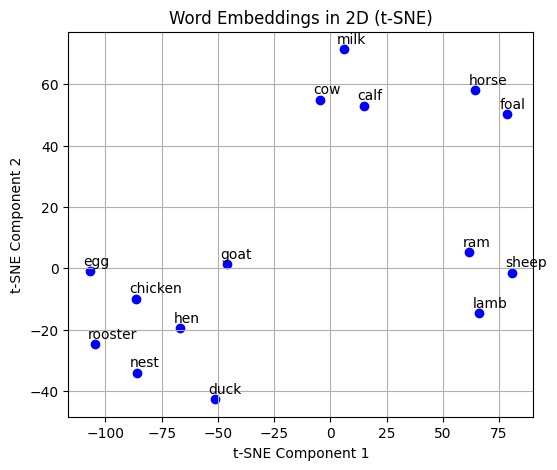

In [ ]:
# Visualize embeddings
vis_words = ["chicken", "rooster", "hen", "egg", "nest", "cow" , "calf", "milk", "sheep", "lamb", "ram", "goat", "horse", "foal", "duck"]
model.visualize_embeddings(vis_words, vocab)

## **Closing This Chapter**

In this chapter, we learned how **words can be mapped into a numerical space** using vectors, a foundational idea in Natural Language Processing known as **Word Embeddings**. We explored **Word2Vec**, and then zoomed in on the **Skip-gram** model, where the goal is simple yet powerful:  
learn a word’s meaning by learning which other words tend to appear around it.

By training a model to predict **context words from a target word**, we saw how semantic relationships naturally emerge without any labeled data. Words with similar meanings end up close to each other in the embedding space, and meaningful relationships are preserved through geometry rather than rules.

These embeddings are:
- **Unsupervised** and data-driven  
- **Robust** to noise and vocabulary size  
- Capable of capturing **semantic and syntactic relationships** between words  

Most importantly, the vectors we learned here are not an end, they are a **starting point**. They form the raw semantic signal that future models will refine, reshape, and elevate.

---

### **What’s Next?**

> **Attention Mechanisms & Transformer Architecture**

We now move beyond static word representations into models that **understand context dynamically**.  
In the next chapter, we’ll study the landmark paper **“Attention Is All You Need”**, and uncover:
- Self-attention  
- Multi-head attention  
- The Transformer architecture  

This is where modern NLP truly begins.